# Stable-Distance Pairs Trading on the STOXX 600

This notebook presents a weekly walk-forward pairs-trading backtest with point-in-time index membership, an internal validation period, transaction costs, and a buy-and-hold benchmark. The notebook explains the research decisions and diagnostics; the reusable implementation is in `pairs_trading/backtest.py`.

**Research question:** can a market-neutral relative-value strategy deliver useful out-of-sample risk-adjusted returns in the STOXX universe?

## Financial intuition

Pairs trading buys the relatively cheap leg and shorts the relatively expensive leg. The signal is a standardized spread:

$$s_t = \log(y_t) - (\alpha + \beta \log(x_t)), \qquad z_t = \frac{s_t - \mu_s}{\sigma_s}.$$

The hedge ratio $\beta$ converts the two stocks into comparable long and short exposures. If $z_t$ is very negative, the strategy buys the spread (long $y$, short $x$); if it is very positive, it shorts the spread. A return is earned only if the spread moves back after entry.

Correlation describes short-run co-movement, while stable-distance selection asks whether normalized price paths remain economically close. The validation checks then reject relationships with large drift, volatility expansion or no mean crossing. A low market beta shows neutrality; it does not guarantee a positive return.

In [1]:
from dataclasses import replace
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import display

MARKET = "stoxx"
METHOD = "distance"
RECOMPUTE = False
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from pairs_trading import (PairsBacktester, StrategyConfig, benchmark_returns,
                           load_market, performance_stats, plot_diagnostics,
                           plot_equity_drawdown, plot_parameter_sensitivity,
                           plot_spread)

RESULTS = ROOT / "results/stoxx_distance"

data = load_market(ROOT / "data" / "cache", MARKET)
config = StrategyConfig(selection_method=METHOD, min_price=1.0)
print(f"{data.prices.shape[1]:,} securities, {data.prices.index[0].date()} to {data.prices.index[-1].date()}")

1,255 securities, 2002-01-04 to 2018-11-30


## Research design and controls against bias

- Formation: 156 weeks.
- Internal validation: the final 52 formation weeks.
- Trading: the next 26 weeks, then repeat.
- Universe: current members with complete, clean formation data.
- Candidate restriction: same sector and market group.
- Trading: enter at +/-2 z, exit inside +/-0.5 z, stop at +/-3.5 z, and close after 12 weeks.
- Cost: 10 basis points per unit of turnover.

For each trading window, the implementation follows this sequence:

1. Reconstruct membership from the latest available historical index weights.
2. Remove incomplete, low-price and extreme-return histories.
3. Restrict comparisons to the same sector and Bloomberg exchange code.
4. Rank training-period pairs by normalized log-price-path distance.
5. Estimate an OLS hedge ratio and test validation-period drift, volatility and mean crossings.
6. Refit accepted relationships on the complete formation window and freeze them.
7. Keep non-overlapping stocks and trade only the following 26 weeks.
8. Repeat using only the information available at the next rebalance date.

No stock is reused within a window. Each selected pair receives one twentieth of portfolio capital. Exchange code is used as a transparent quote-market proxy, but it is not a substitute for security-level currency data.

In [2]:
parameter_table = pd.Series({
    "Formation weeks": config.formation_weeks,
    "Validation weeks": config.validation_weeks,
    "Trading weeks": config.trading_weeks,
    "Maximum pairs": config.n_pairs,
    "Minimum return correlation": config.min_return_corr,
    "Entry z-score": config.entry_z,
    "Exit z-score": config.exit_z,
    "Stop z-score": config.stop_z,
    "Maximum holding weeks": config.max_holding_weeks,
    "Cost per unit turnover": config.fee,
}, name="Value").to_frame()
parameter_table

,Value
Formation weeks,156.000
Validation weeks,52.000
Trading weeks,26.000
Maximum pairs,20.000
Minimum return correlation,0.400
Entry z-score,2.000
Exit z-score,0.500
Stop z-score,3.500
Maximum holding weeks,12.000
Cost per unit turnover,0.001


## Run or load the backtest

Set `RECOMPUTE=True` to repeat pair selection and trading from the cached market data. The default loads the saved deterministic result so the notebook opens quickly. Gross returns exclude the stated fee; net returns include it.

In [3]:
if RECOMPUTE:
    backtester = PairsBacktester(data, config)
    strategy_net, selections = backtester.run(progress=True)
    strategy_gross = PairsBacktester(data, replace(config, fee=0.0)).trade_selections(selections)
    benchmark = benchmark_returns(data, strategy_net.index)
else:
    saved = pd.read_csv(RESULTS / "weekly_returns.csv", index_col=0, parse_dates=True)
    strategy_net = saved["strategy_net"]
    strategy_gross = saved["strategy_gross"]
    benchmark = saved["benchmark"]

metrics = pd.DataFrame({
    "Strategy net": performance_stats(strategy_net, benchmark),
    "Strategy gross": performance_stats(strategy_gross, benchmark),
    "Benchmark": performance_stats(benchmark),
})
metrics

,Strategy net,Strategy gross,Benchmark
Annual volatility,0.014830,0.014791,0.182880
CAGR,0.002091,0.006113,0.025542
Market beta,0.008490,0.008304,NaN
Market correlation,0.104692,0.102677,NaN
Max drawdown,-0.034301,-0.025614,-0.601509
Positive weeks,0.499312,0.515818,0.559835
Sharpe (rf=0),0.148259,0.419451,0.231152
Sortino,0.232263,0.664276,0.281120
Total return,0.029635,0.088944,0.422789
Worst week,-0.007299,-0.007299,-0.215354


In [4]:
selected = pd.read_csv(RESULTS / "selected_pairs.csv", parse_dates=["trading_start"])
starts = data.prices.index[range(config.formation_weeks, len(data.prices) - 1,
                                 config.trading_weeks)]
counts = pd.Series(0, index=starts, dtype=int)
counts.update(selected.groupby("trading_start").size())

print(f"Selected pair instances: {len(selected):,}")
print(f"Average selected pairs per window: {counts.mean():.1f}")
print(f"Empty selection windows: {(counts == 0).sum()} of {len(counts)}")
display_columns = [column for column in
                   ["trading_start", "y", "x", "sector", "group", "q_value",
                    "distance", "half_life", "validation_mean_z"]
                   if column in selected]
selected[display_columns].head(10)

Selected pair instances: 560
Average selected pairs per window: 20.0
Empty selection windows: 0 of 28


,trading_start,y,x,sector,group,distance,half_life,validation_mean_z
0,2004-12-31,SSE LN Equity,PNN LN Equity,Utilities,LN,0.002295,4.060155,-0.614160
1,2004-12-31,BDEV LN Equity,BVS LN Equity,"Consumer, Cyclical",LN,0.002441,3.466507,-0.100271
2,2004-12-31,SGRO LN Equity,BXTN LN Equity,Financial,LN,0.002595,2.448404,-0.344734
3,2004-12-31,MGGT LN Equity,IMI LN Equity,Industrial,LN,0.002943,2.522605,0.839518
4,2004-12-31,NG/ LN Equity,UU/ LN Equity,Utilities,LN,0.003078,4.405343,-0.324620
5,2004-12-31,MB IM Equity,AL IM Equity,Financial,IM,0.003213,6.185088,0.884336
6,2004-12-31,MS IM Equity,MN IM Equity,Communications,IM,0.003297,3.567783,-0.511836
7,2004-12-31,SEBA SS Equity,SWEDA SS Equity,Financial,SS,0.003836,4.405538,0.091878
8,2004-12-31,BIRG ID Equity,AIBG ID Equity,Financial,ID,0.003890,5.561265,-0.072318
9,2004-12-31,ABF LN Equity,RB/ LN Equity,"Consumer, Non-cyclical",LN,0.004587,7.519382,-0.725755


## What the selected-pair fields mean

- `distance` is the mean squared gap between normalized training price paths.
- `beta` is the frozen hedge ratio used to scale the short leg.
- `half_life` estimates the speed of mean reversion in weeks.
- `validation_mean_z` measures spread drift between training and validation.
- `validation_std_ratio` compares validation spread volatility with training volatility.
- `validation_crossings` counts how often the validation spread crossed its training mean.

These are formation-period diagnostics, not guarantees about the next trading window.

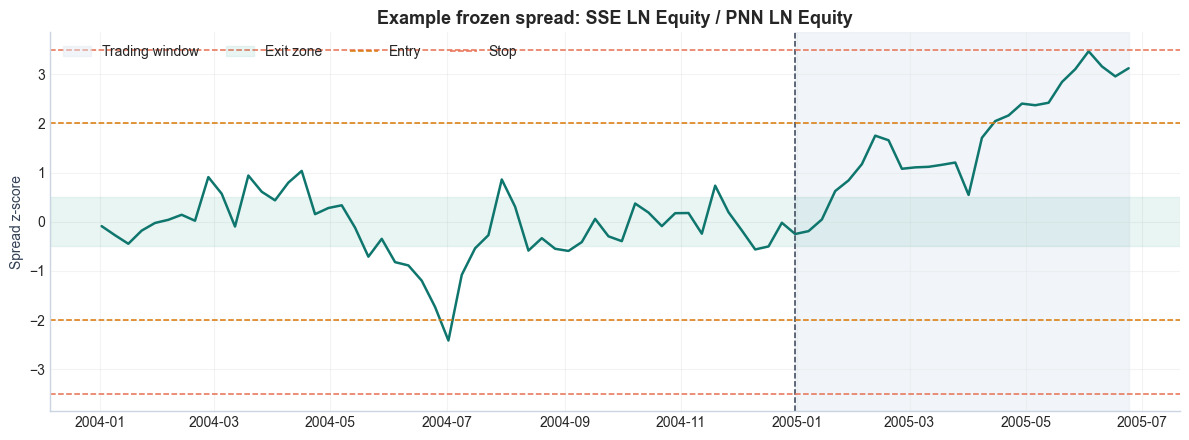

In [5]:
example = selected.iloc[0]
trade_start = example["trading_start"]
trade_position = data.prices.index.get_loc(trade_start)
view = slice(max(0, trade_position - config.validation_weeks),
             min(len(data.prices), trade_position + config.trading_weeks))
spread = (np.log(data.prices[example["y"]].iloc[view])
          - example["alpha"]
          - example["beta"] * np.log(data.prices[example["x"]].iloc[view]))
z_score = (spread - example["mean"]) / example["sigma"]

_ = plot_spread(z_score, trade_start, config,
                f"Example frozen spread: {example['y']} / {example['x']}")

In [6]:
active = (strategy_net.abs() + strategy_gross.abs()) > 1e-12
midpoint = len(strategy_net) // 2
diagnostics = pd.Series({
    "Selected pair instances": len(selected),
    "Average pairs per window": counts.mean(),
    "Empty selection windows": (counts == 0).sum(),
    "Active-week share": active.mean(),
    "Positive active weeks": (strategy_net[active] > 0).mean(),
    "Average half-life (weeks)": selected["half_life"].mean(),
    "Gross-to-net wealth drag": (1 + strategy_gross).prod() - (1 + strategy_net).prod(),
    "First-half net return": (1 + strategy_net.iloc[:midpoint]).prod() - 1,
    "Second-half net return": (1 + strategy_net.iloc[midpoint:]).prod() - 1,
}, name="Diagnostic")
diagnostics.to_frame()

,Diagnostic
Selected pair instances,560.000000
Average pairs per window,20.000000
Empty selection windows,0.000000
Active-week share,1.000000
Positive active weeks,0.499312
Average half-life (weeks),5.683130
Gross-to-net wealth drag,0.059309
First-half net return,-0.006177
Second-half net return,0.036035


In [7]:
method_comparison = {}
for method in ["cointegration", "distance"]:
    result = pd.read_csv(ROOT / f"results/stoxx_{method}/metrics.csv", index_col=0)
    method_comparison[method.title()] = result["Strategy net"]
method_comparison = pd.DataFrame(method_comparison).T
method_comparison[["Total return", "CAGR", "Sharpe (rf=0)",
                   "Max drawdown", "Market beta"]]

,Total return,CAGR,Sharpe (rf=0),Max drawdown,Market beta
Cointegration,-0.099226,-0.007447,-0.761850,-0.109052,0.005575
Distance,0.029635,0.002091,0.148259,-0.034301,0.008490


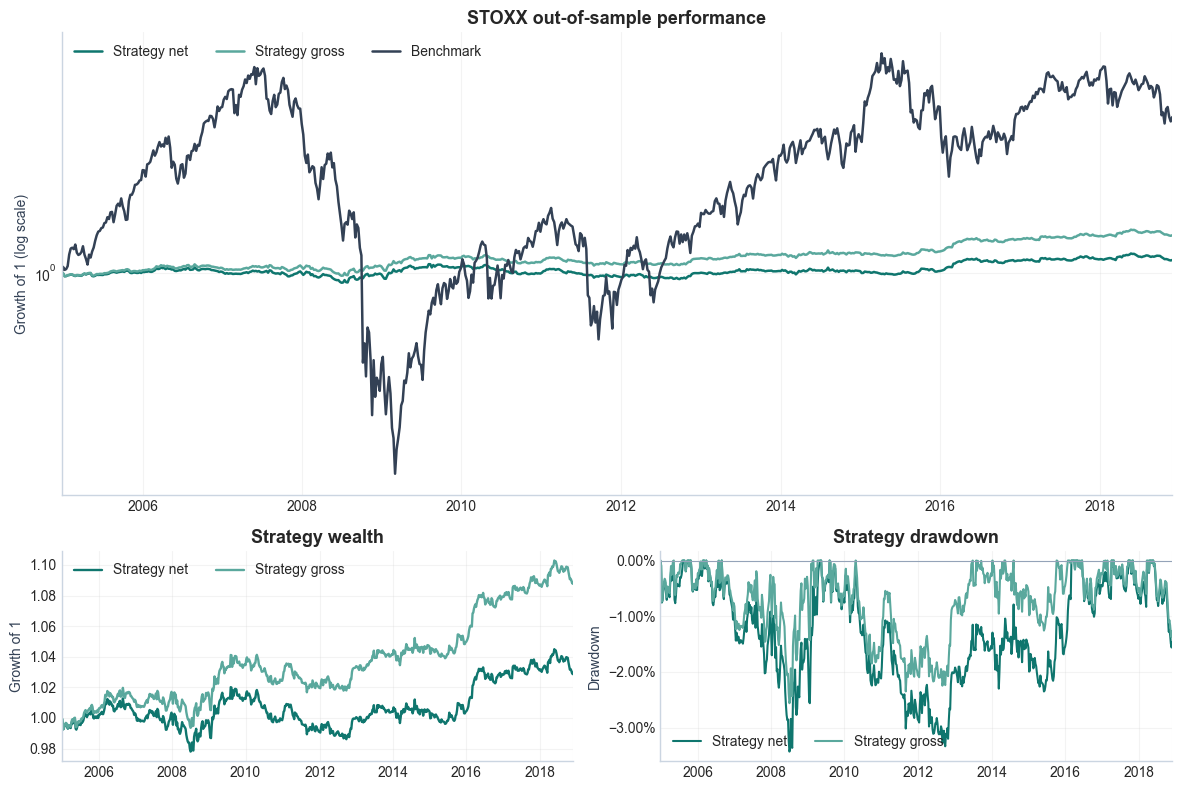

In [8]:
returns = pd.DataFrame({
    "Strategy net": strategy_net,
    "Strategy gross": strategy_gross,
    "Benchmark": benchmark,
})
_ = plot_equity_drawdown(returns, f"{MARKET.upper()} out-of-sample performance")

## Stability through time

A positive full-sample return can hide long weak periods. Annual returns, rolling Sharpe and selected-pair counts show whether performance and opportunity availability are stable. The rolling Sharpe is descriptive because overlapping 52-week windows are not independent.

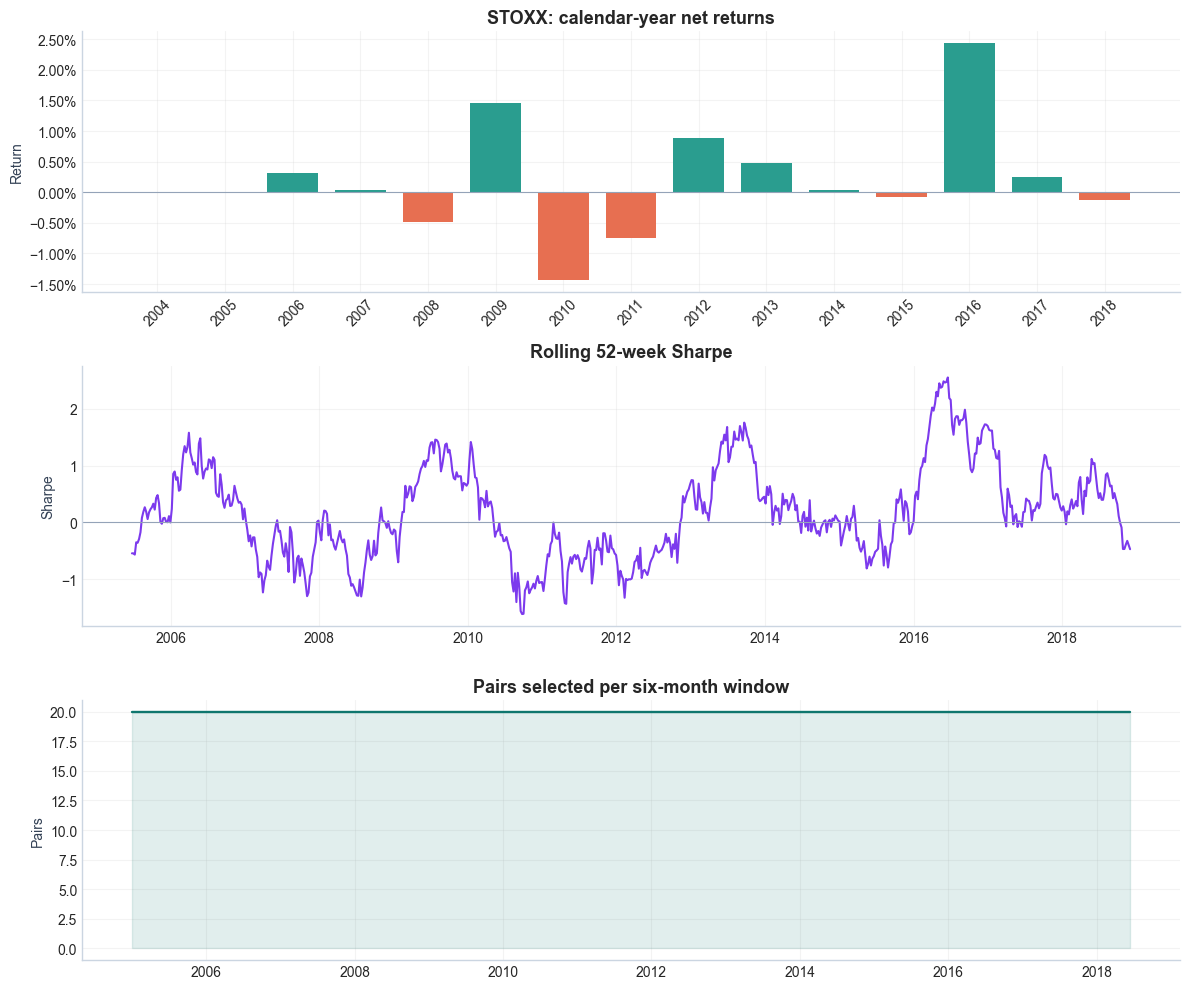

In [9]:
_, annual_returns, rolling_sharpe = plot_diagnostics(
    strategy_net, benchmark, counts, MARKET.upper()
)

## Trading-rule sensitivity

The entry-exit matrix restores the original notebook's useful Sharpe diagnostic using the improved backtest engine. Pair selection remains fixed, while the trading layer is rerun for each parameter combination. The cost panel shows how quickly implementation costs consume the edge, and the final table changes one assumption at a time.

This is **descriptive sensitivity analysis, not parameter optimization**. Every value reuses the same complete evaluation period, so the highest Sharpe cell cannot be presented as a proven improvement or used to replace the baseline without a nested walk-forward test.

Exit z-score,0.000000,0.500000,1.000000
Entry z-score,,,
1.500000,0.10,0.34,0.37
2.000000,-0.04,0.15,0.24
2.500000,-0.02,-0.02,0.03


,Total return,CAGR,Sharpe (rf=0),Max drawdown
Cost per unit turnover (bps),,,,
0,+8.89%,+0.61%,0.42,-2.56%
5,+5.89%,+0.41%,0.28,-3.00%
10,+2.96%,+0.21%,0.15,-3.43%
20,-2.65%,-0.19%,-0.12,-5.20%


,Total return,CAGR,Sharpe (rf=0),Max drawdown,Annual volatility
Baseline,0.029635,0.002091,0.148259,-0.034301,0.014830
Entry 1.5,0.084202,0.005799,0.343918,-0.026872,0.017246
Entry 2.5,-0.003438,-0.000246,-0.015907,-0.038518,0.011406
Exit 0.75,0.033409,0.002353,0.170053,-0.034691,0.014435
Stop 4.0,0.012385,0.000881,0.060726,-0.054187,0.016824
Hold 20 weeks,0.013846,0.000984,0.071831,-0.040706,0.015324
Fee 5 bps,0.058876,0.004100,0.283732,-0.029967,0.014808
Fee 20 bps,-0.026452,-0.001916,-0.121322,-0.051967,0.014892


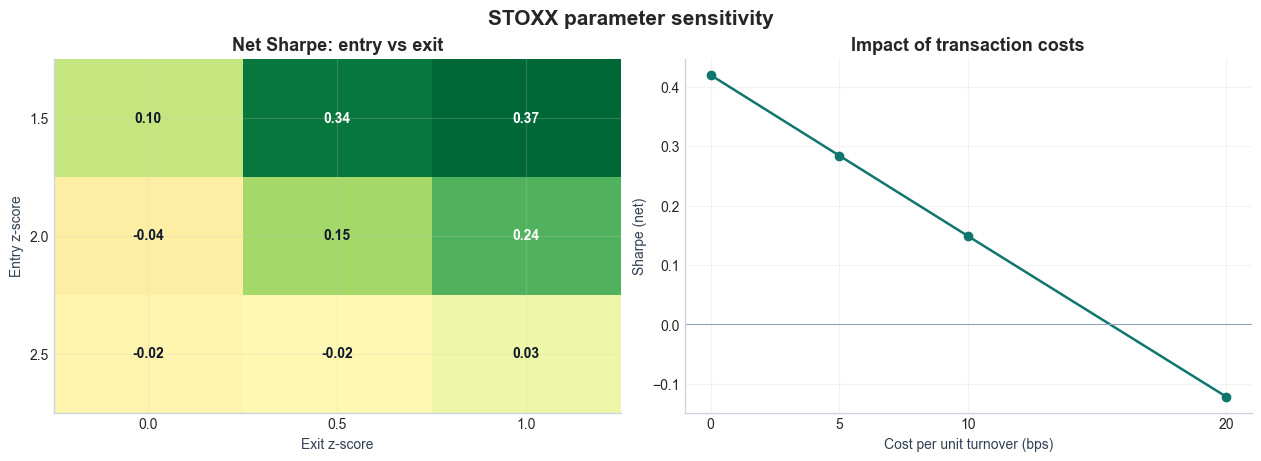

In [10]:
start_positions = range(config.formation_weeks, len(data.prices) - 1, config.trading_weeks)
selection_map = {
    position: selected.loc[selected["trading_start"].eq(data.prices.index[position])].drop(columns="trading_start")
    for position in start_positions
}
def evaluate_scenario(**changes):
    scenario_config = replace(config, **changes)
    scenario_returns = PairsBacktester(data, scenario_config).trade_selections(selection_map)
    return performance_stats(scenario_returns)


entry_values = [1.5, 2.0, 2.5]
exit_values = [0.0, 0.5, 1.0]
sharpe_grid = pd.DataFrame(
    [[evaluate_scenario(entry_z=entry, exit_z=exit_)["Sharpe (rf=0)"]
      for exit_ in exit_values] for entry in entry_values],
    index=pd.Index(entry_values, name="Entry z-score"),
    columns=pd.Index(exit_values, name="Exit z-score"),
)
fee_table = pd.DataFrame({
    fee_bps: evaluate_scenario(fee=fee_bps / 10_000)
    for fee_bps in [0, 5, 10, 20]
}).T
fee_table.index.name = "Cost per unit turnover (bps)"
plot_parameter_sensitivity(sharpe_grid, fee_table, f"{MARKET.upper()} parameter sensitivity")
display(sharpe_grid.style.format("{:.2f}").set_caption("Net Sharpe matrix"))
display(fee_table[["Total return", "CAGR", "Sharpe (rf=0)", "Max drawdown"]]
        .style.format({"Total return": "{:+.2%}", "CAGR": "{:+.2%}",
                       "Sharpe (rf=0)": "{:.2f}", "Max drawdown": "{:.2%}"})
        .set_caption("Transaction-cost sensitivity"))

scenarios = {
    "Baseline": {},
    "Entry 1.5": {"entry_z": 1.5},
    "Entry 2.5": {"entry_z": 2.5},
    "Exit 0.75": {"exit_z": 0.75},
    "Stop 4.0": {"stop_z": 4.0},
    "Hold 20 weeks": {"max_holding_weeks": 20},
    "Fee 5 bps": {"fee": 0.0005},
    "Fee 20 bps": {"fee": 0.0020},
}
sensitivity = pd.DataFrame({
    label: evaluate_scenario(**changes) for label, changes in scenarios.items()
}).T
assert np.isclose(sensitivity.loc["Baseline", "Total return"], metrics.loc["Total return", "Strategy net"])
sensitivity[["Total return", "CAGR", "Sharpe (rf=0)",
             "Max drawdown", "Annual volatility"]]

## Result interpretation

### What worked

- The distance model earns **+2.96% net** versus **+8.89% gross**, with a **0.15 Sharpe**, **-3.43% maximum drawdown** and market beta of approximately **0.008**. It provides much lower directional market risk than the STOXX benchmark.
- It clearly outperforms the robust cointegration alternative on this sample, whose net total return is **-9.92%**. This supports using a stable-distance baseline for this dataset.

### What did not work well

- CAGR is only about **0.21%**, far below buy and hold. The strategy may diversify equity risk, but it does not replace the index.
- The model selects all **20 pairs in every window** and is active almost every week. Unlike the SPX result, low risk does not come from holding cash; it comes from small pair-level allocations and long-short netting.
- Transaction costs reduce terminal wealth by about **5.93 percentage points**, roughly two thirds of the gross gain. At 20 basis points per unit turnover, the strategy loses about **2.65%**.
- The first half loses about **0.62%**, while the second half gains about **3.60%**. This is evidence of regime dependence rather than a uniformly stable edge.
- Lowering entry from 2.0 to 1.5 improves the historical result to about **8.42%** in this diagnostic, but choosing it after observing the full sample would be overfitting. It is a hypothesis for a new validation design, not the new official parameter.

## Model-improvement roadmap

1. **Freeze the current baseline.** Keep these results unchanged as the reference model.
2. **Use nested walk-forward tuning.** Choose entry, exit, stop and holding rules only inside each formation period; evaluate once in the following untouched window. Prefer a stable parameter region over the single best Sharpe.
3. **Add security-level currency data.** Convert both legs consistently and distinguish listing exchange from quote currency. This is especially important for a pan-European universe.
4. **Add a trade ledger.** Record every entry, exit, holding period, stop, gross P&L and cost. This allows attribution by country, sector, pair, regime and exit reason.
5. **Improve execution realism.** Trade at the next executable price and include bid-ask spread, borrow fee and availability, dividends, financing and cash collateral yield.
6. **Refresh the data.** Freeze the specification before testing post-2018 point-in-time constituents and corporate actions. This is the most important test of whether the edge still exists.
7. **Test modest extensions only after the baseline.** Candidates include time-varying hedge ratios, market-volatility regime filters and volatility-scaled pair allocation. Each extension needs an ablation test against the baseline.
8. **Paper trade before live use.** Monitor data quality, signal latency, borrow availability, rejected orders and realized slippage for several months.

## Conclusion

The STOXX distance result is the most promising strategy result in the project, but most of its gross edge is consumed by costs and it is not stable across subperiods. It is a research baseline for diversification, not yet a production strategy.